<a href="https://colab.research.google.com/github/Frankieche24/White-Wine-Quality/blob/main/Machine_Learning_2_00.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import (
    train_test_split, KFold, TimeSeriesSplit,
    cross_val_score, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

In [3]:
# =============================================================================
# --- 0. ORGANISE DATA; DEAL WITH MISSING VALUES; BUILD X, y
# =============================================================================

# prompt: Load the CSV, parse dates, resample to monthly averages, build lagged
# features for t-2 and t-1 months, add a sine/cosine seasonality variable,
# then split into X (predictors) and y (target). Sort everything chronologically.

df = pd.read_csv("Petrignano Machine learning.csv")

# Parse dates (format is day-first, e.g. 1/1/2009)
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df = df.sort_values("Date").reset_index(drop=True)

In [4]:
# ── Aggregate to monthly means ────────────────────────────────────────────────
# Daily missing values (27 in DP25, 1 in Volume) are automatically filled by
# averaging over the rest of the month, so no explicit imputation is needed.
monthly = df.resample("MS", on="Date").mean()   # MS = Month Start frequency

# ── Seasonality variable ──────────────────────────────────────────────────────
# Sine-encode the month number so January and December are close together.
# Modification: used both sin and cos so the model can reconstruct full phase.
monthly["month_sin"] = np.sin(2 * np.pi * monthly.index.month / 12)
monthly["month_cos"] = np.cos(2 * np.pi * monthly.index.month / 12)

# ── Build lagged features (t-2 and t-1) ──────────────────────────────────────
# prompt: For every column in the monthly dataframe (except the target),
# create two shifted copies: one for 2 months ago and one for 1 month ago.
# The target column (DP25) is also shifted so we predict the CURRENT month's
# value from the previous two months.

feature_cols = monthly.columns.tolist()          # all columns including DP25
lagged_frames = []

for lag in [2, 1]:
    shifted = monthly[feature_cols].shift(lag)
    shifted.columns = [f"{c}_lag{lag}" for c in feature_cols]
    lagged_frames.append(shifted)

lagged_df = pd.concat(lagged_frames, axis=1)

# Target: current month's DP25
lagged_df["target_DP25"] = monthly["Depth_to_Groundwater_P25"]

# Drop the first 2 rows that have NaN lags after shifting
lagged_df = lagged_df.dropna().reset_index(drop=True)

# Separate predictors and response
X = lagged_df.drop(columns=["target_DP25"])
y = lagged_df["target_DP25"]

print(f"Dataset shape after lagging: X={X.shape}, y={y.shape}")
print(f"Feature columns ({len(X.columns)}):\n  {list(X.columns)}\n")


Dataset shape after lagging: X=(136, 16), y=(136,)
Feature columns (16):
  ['Rainfall_Bastia_Umbra_lag2', 'Depth_to_Groundwater_P25_lag2', 'Temperature_Bastia_Umbra_lag2', 'Temperature_Petrignano_lag2', 'Volume_C10_Petrignano_lag2', 'Hydrometry_Fiume_Chiascio_Petrignano_lag2', 'month_sin_lag2', 'month_cos_lag2', 'Rainfall_Bastia_Umbra_lag1', 'Depth_to_Groundwater_P25_lag1', 'Temperature_Bastia_Umbra_lag1', 'Temperature_Petrignano_lag1', 'Volume_C10_Petrignano_lag1', 'Hydrometry_Fiume_Chiascio_Petrignano_lag1', 'month_sin_lag1', 'month_cos_lag1']



In [5]:
# =============================================================================
# --- 1. THE HARD SPLIT (chronological — no shuffle)
# =============================================================================

# prompt: Split X and y into training and test sets using the last 20% of
# rows as the test set. shuffle=False preserves chronological order.

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"Train size: {len(X_train_full)} months  |  Test size: {len(X_test)} months\n")


Train size: 108 months  |  Test size: 28 months



In [6]:
# =============================================================================
# --- 2. DEFINE THE TWO CV STRATEGIES
# =============================================================================

cv_naive    = KFold(n_splits=5, shuffle=True, random_state=42)
cv_temporal = TimeSeriesSplit(n_splits=5)


In [7]:
# =============================================================================
# --- 3. EXPERIMENT WITH A FIXED MODEL
# =============================================================================

# prompt: Build a Pipeline with StandardScaler and DecisionTreeRegressor
# (max_depth=10). Evaluate it with both CV strategies using cross_val_score,
# then train on the full training set and score on the held-out test set.

pipe = Pipeline([
    ("scaler",     StandardScaler()),
    ("regressor",  DecisionTreeRegressor(max_depth=10, random_state=42))
])

# Strategy 1: Naive (Shuffled) — leaks future data into validation folds
scores_naive = cross_val_score(
    pipe, X_train_full, y_train_full, cv=cv_naive, scoring="r2"
)

# Strategy 2: Temporal (Sequential) — respects chronological order
scores_temporal = cross_val_score(
    pipe, X_train_full, y_train_full, cv=cv_temporal, scoring="r2"
)

print("=" * 55)
print("SECTION 3 — Fixed Model (DecisionTree max_depth=10)")
print("=" * 55)
print(f"Naive CV R2:    {scores_naive.mean():.4f}  (+/- {scores_naive.std():.4f})")
print(f"Temporal CV R2: {scores_temporal.mean():.4f}  (+/- {scores_temporal.std():.4f})")

# Train on all training data and evaluate on the unseen "future"
pipe.fit(X_train_full, y_train_full)
final_test_r2 = r2_score(y_test, pipe.predict(X_test))
print(f"\nActual Test R2 on held-out data: {final_test_r2:.4f}")



SECTION 3 — Fixed Model (DecisionTree max_depth=10)
Naive CV R2:    0.9229  (+/- 0.0488)
Temporal CV R2: 0.1179  (+/- 0.6519)

Actual Test R2 on held-out data: -0.4845


In [8]:
# =============================================================================
# --- 4. MODEL SELECTION & EVALUATION
# =============================================================================

def evaluate_model_selection(X_train, y_train, X_test, y_test, cv_strategy, name):
    """
    Runs GridSearchCV over DecisionTree max_depth values using the given
    cv_strategy, then evaluates the best model on the independent test set.
    """

    # prompt: Inside evaluate_model_selection, build a Pipeline with
    # StandardScaler and DecisionTreeRegressor. Define a param_grid with at
    # least 4 max_depth values. Run GridSearchCV with the provided cv_strategy
    # and r2 scoring, fit it, then predict on X_test and print results.

    # STEP A — Pipeline
    pipe = Pipeline([
        ("scaler",    StandardScaler()),
        ("regressor", DecisionTreeRegressor(random_state=42))
    ])

    # STEP B — Hyperparameter grid (at least 4 depths as required)
    param_grid = {
        "regressor__max_depth": [2, 4, 6, 8, 10, 15, 20, None]
        # None = fully grown tree; useful to show overfitting risk
    }

    # STEP C — GridSearchCV with the supplied cv_strategy
    grid = GridSearchCV(
        estimator  = pipe,
        param_grid = param_grid,
        cv         = cv_strategy,
        scoring    = "r2",
        refit      = True,      # re-trains best model on full X_train
        n_jobs     = -1
    )
    grid.fit(X_train, y_train)

    # STEP D — Evaluate best estimator on the independent test set
    y_pred  = grid.predict(X_test)          # uses best_estimator_ automatically
    test_r2 = r2_score(y_test, y_pred)

    print(f"\n{'=' * 55}")
    print(f"Results for: {name}")
    print(f"{'=' * 55}")
    print(f"Best Parameters found:        {grid.best_params_}")
    print(f"Internal CV Score  (R2):      {grid.best_score_:.4f}")
    print(f"Independent Test Score (R2):  {test_r2:.4f}")
    gap = grid.best_score_ - test_r2
    print(f"Optimism gap (CV - Test):     {gap:.4f}")

    return grid

In [10]:
# =============================================================================
# --- 5. RUNNING THE COMPARISON
# =============================================================================

print("\n" + "=" * 55)
print("SECTION 5 — Model Selection Comparison")
print("=" * 55)

result_naive    = evaluate_model_selection(
    X_train_full, y_train_full, X_test, y_test,
    cv_naive,    "Naive K-Fold"
)

result_temporal = evaluate_model_selection(
    X_train_full, y_train_full, X_test, y_test,
    cv_temporal, "Temporal Split"
)




SECTION 5 — Model Selection Comparison

Results for: Naive K-Fold
Best Parameters found:        {'regressor__max_depth': 8}
Internal CV Score  (R2):      0.9295
Independent Test Score (R2):  -0.4434
Optimism gap (CV - Test):     1.3729

Results for: Temporal Split
Best Parameters found:        {'regressor__max_depth': 4}
Internal CV Score  (R2):      0.1786
Independent Test Score (R2):  -0.4367
Optimism gap (CV - Test):     0.6153


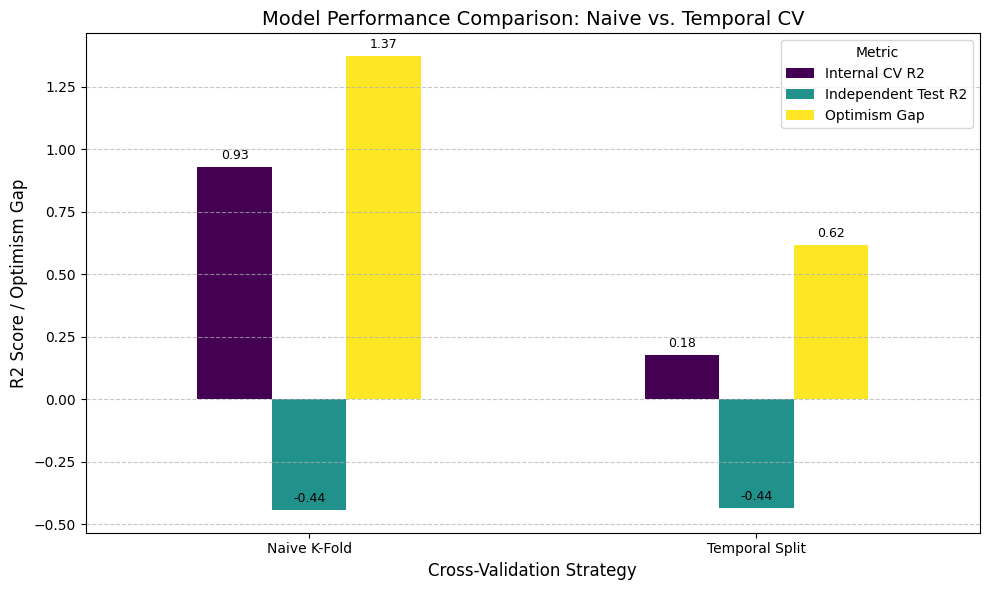

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract metrics from the results
metrics_data = {
    'Strategy': ['Naive K-Fold', 'Temporal Split'],
    'Internal CV R2': [result_naive.best_score_, result_temporal.best_score_],
    'Independent Test R2': [r2_score(y_test, result_naive.predict(X_test)), r2_score(y_test, result_temporal.predict(X_test))]
}

metrics_df = pd.DataFrame(metrics_data)
metrics_df['Optimism Gap'] = metrics_df['Internal CV R2'] - metrics_df['Independent Test R2']

# Plotting the comparison
fig, ax = plt.subplots(figsize=(10, 6))

metrics_df.set_index('Strategy').plot(kind='bar', ax=ax, rot=0, colormap='viridis')

ax.set_title('Model Performance Comparison: Naive vs. Temporal CV', fontsize=14)
ax.set_ylabel('R2 Score / Optimism Gap', fontsize=12)
ax.set_xlabel('Cross-Validation Strategy', fontsize=12)
ax.legend(title='Metric', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of the bars
for container in ax.containers:
    for i, bar in enumerate(container):
        value = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f'{value:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()